<a href="https://colab.research.google.com/github/computacao-aplicada/lab01-eda-pedroluizforlan/blob/main/wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/wine-quality/winequality-red.csv', sep=';')

def classify_quality(q):
    if q <= 5:
        return 'Ruim'
    elif q == 6:
        return 'Medio'
    else:
        return 'Bom'

df['quality_label'] = df['quality'].apply(classify_quality)
print(f'Dataset carregado com sucesso! Shape: {df.shape}')
df.head(10)

Dataset carregado com sucesso! Shape: (1599, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Ruim
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Ruim
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Ruim
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Medio
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Ruim
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,Ruim
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,Ruim
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,Bom
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,Bom
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,Ruim


In [3]:
print("Distribuição das classes:")
print(df['quality_label'].value_counts())

Distribuição das classes:
quality_label
Ruim     744
Medio    638
Bom      217
Name: count, dtype: int64


In [4]:
num_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol', 'quality'
]

df[num_cols].describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


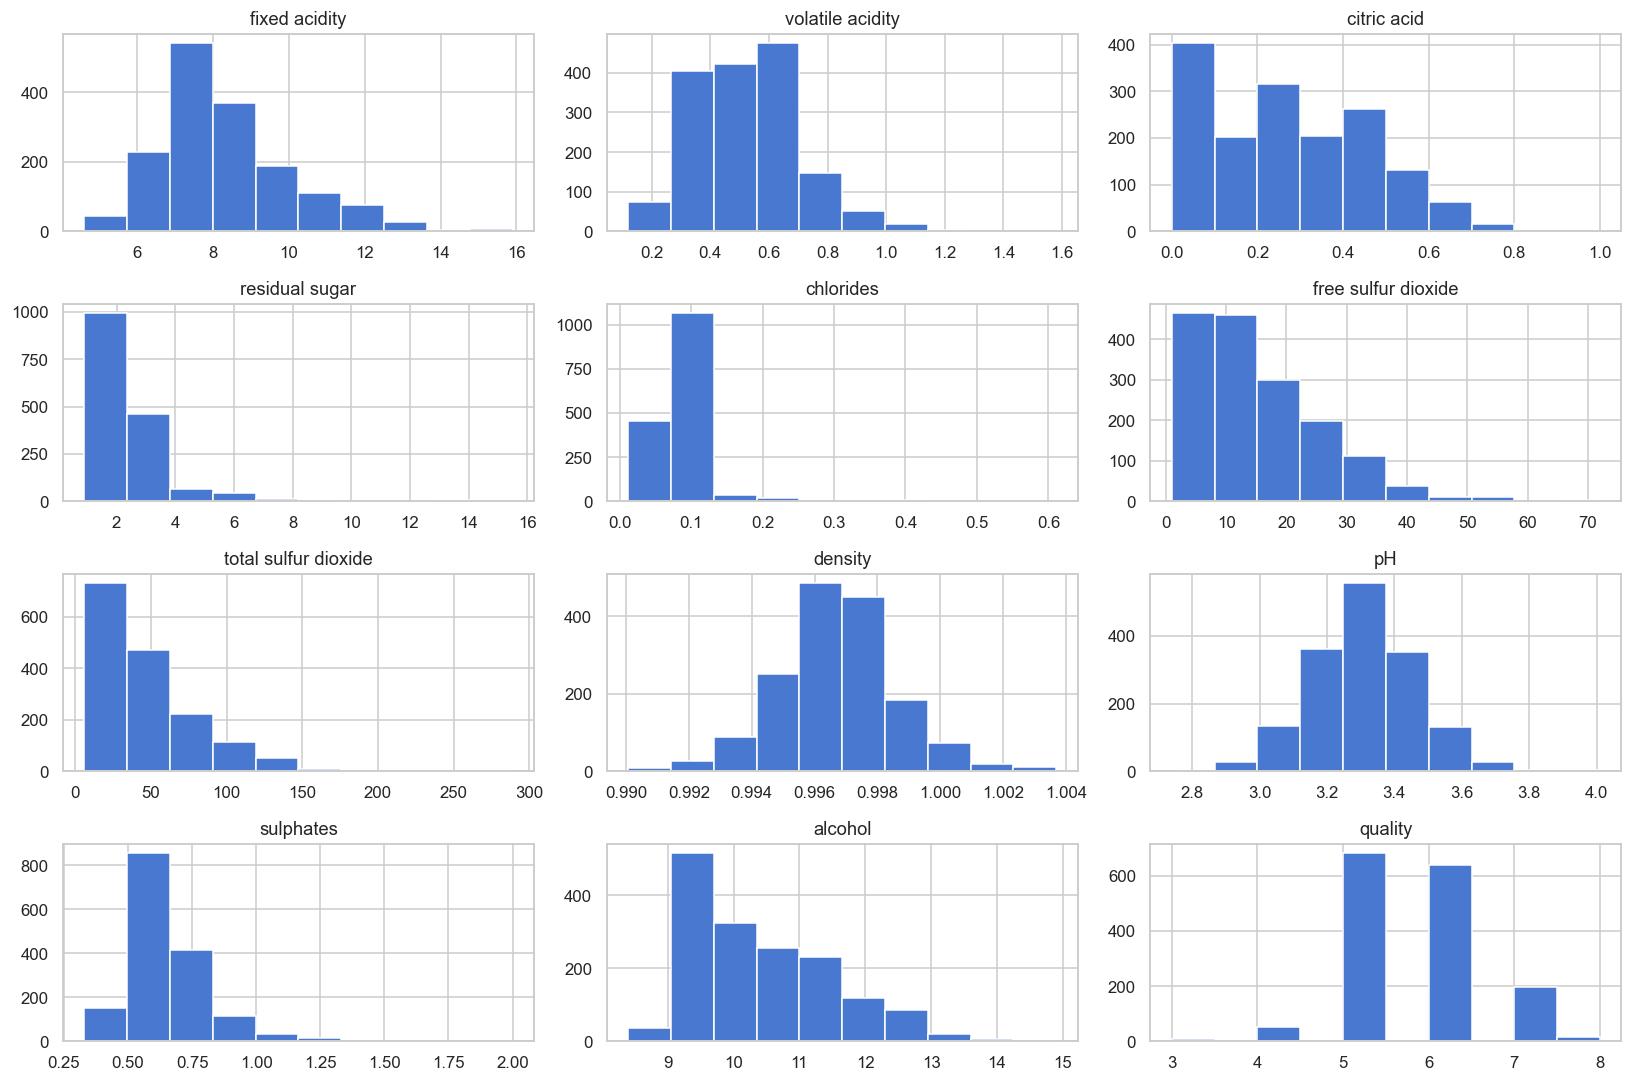

In [5]:
df[num_cols].hist(figsize=(15,10), bins=10)
plt.tight_layout()
plt.show()

Correlação entre álcool e qualidade: 0.476

Estatísticas de álcool por qualidade:
                mean  median   std
quality_label                     
Bom            11.52    11.6  1.00
Medio          10.63    10.5  1.05
Ruim            9.93     9.7  0.76


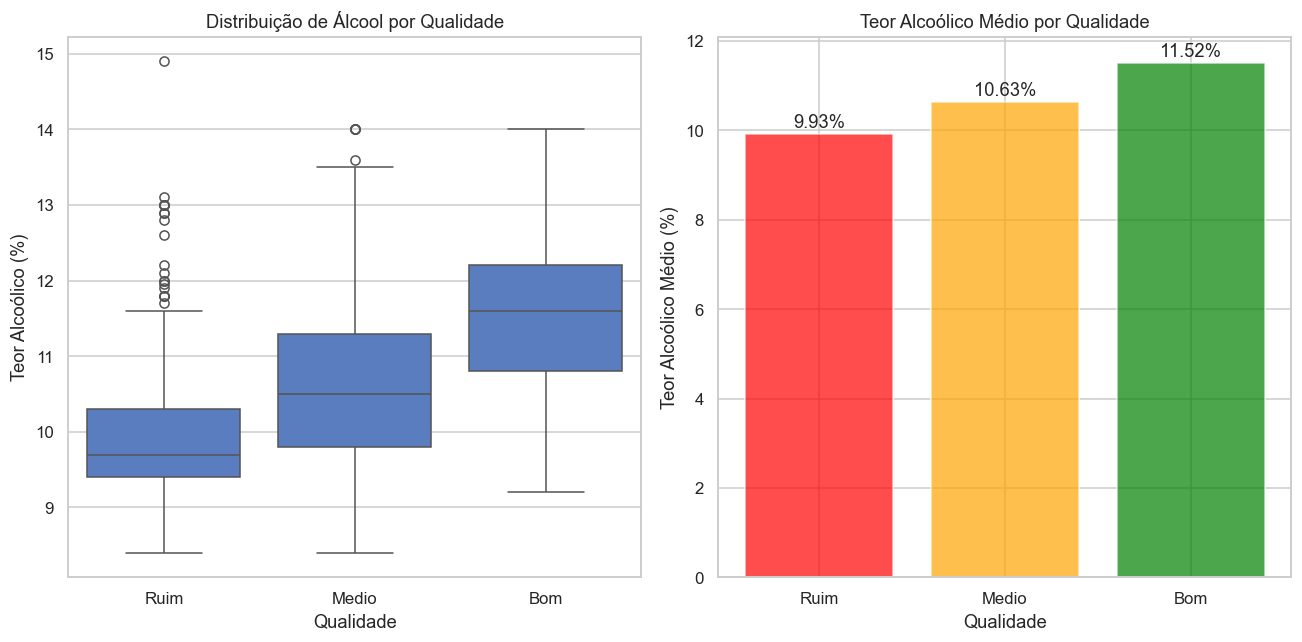

In [6]:
# DESCOBERTA 1: Relação entre Teor Alcoólico e Qualidade

correlation_alcohol_quality = df['alcohol'].corr(df['quality'])
print(f'Correlação entre álcool e qualidade: {correlation_alcohol_quality:.3f}')

alcohol_stats = df.groupby('quality_label')['alcohol'].agg(['mean', 'median', 'std']).round(2)
print('\nEstatísticas de álcool por qualidade:')
print(alcohol_stats)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='quality_label', y='alcohol', order=['Ruim', 'Medio', 'Bom'])
plt.title('Distribuição de Álcool por Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Teor Alcoólico (%)')

plt.subplot(1, 2, 2)
quality_order = ['Ruim', 'Medio', 'Bom']
means = [df[df['quality_label'] == q]['alcohol'].mean() for q in quality_order]
plt.bar(quality_order, means, color=['red', 'orange', 'green'], alpha=0.7)
plt.title('Teor Alcoólico Médio por Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Teor Alcoólico Médio (%)')

for i, v in enumerate(means):
    plt.text(i, v + 0.05, f'{v:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Correlação entre acidez volátil e qualidade: -0.391

Estatísticas de acidez volátil por qualidade:
                mean  median    std
quality_label                      
Bom            0.406    0.37  0.145
Medio          0.497    0.49  0.161
Ruim           0.590    0.59  0.178

Teste t entre vinhos Ruins e Bons:
p-value: 2.40e-40 (diferença significativa)


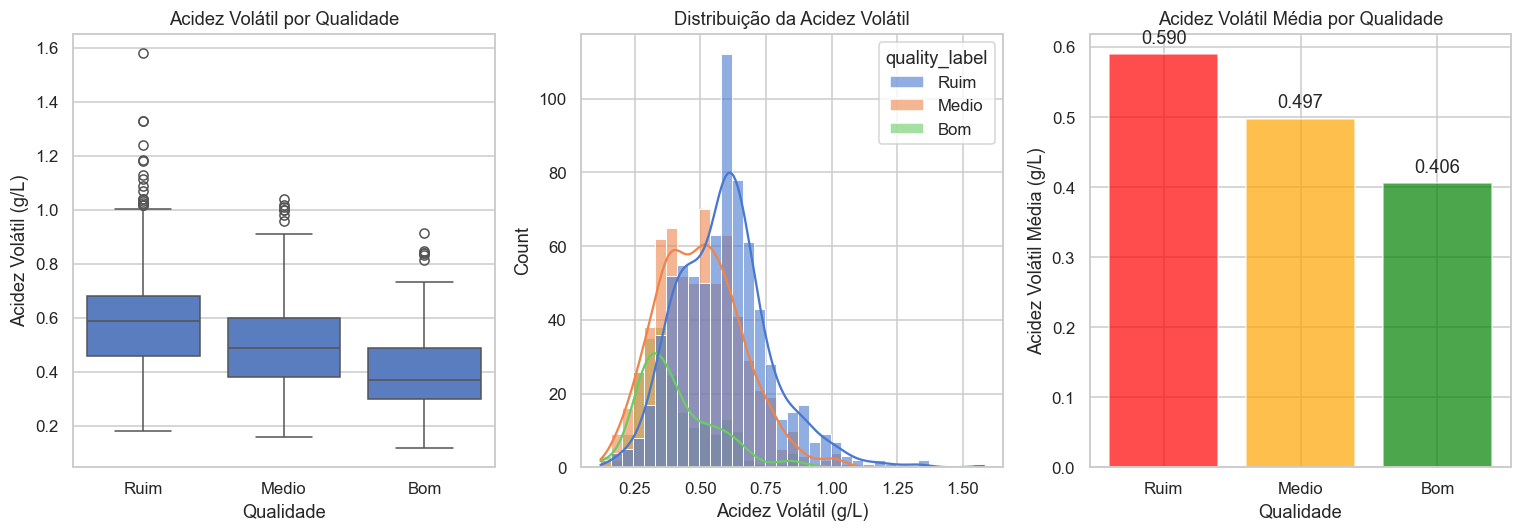

In [7]:
# DESCOBERTA 2: Acidez Volátil como Indicador de Qualidade

correlation_volatile_quality = df['volatile acidity'].corr(df['quality'])
print(f'Correlação entre acidez volátil e qualidade: {correlation_volatile_quality:.3f}')

volatile_stats = df.groupby('quality_label')['volatile acidity'].agg(['mean', 'median', 'std']).round(3)
print('\nEstatísticas de acidez volátil por qualidade:')
print(volatile_stats)

ruim = df[df['quality_label'] == 'Ruim']['volatile acidity']
bom = df[df['quality_label'] == 'Bom']['volatile acidity']
t_stat, p_value = stats.ttest_ind(ruim, bom)
print(f'\nTeste t entre vinhos Ruins e Bons:')
print(f'p-value: {p_value:.2e} (diferença {"significativa" if p_value < 0.05 else "não significativa"})')

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='quality_label', y='volatile acidity', order=['Ruim', 'Medio', 'Bom'])
plt.title('Acidez Volátil por Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Acidez Volátil (g/L)')

plt.subplot(1, 3, 2)
sns.histplot(data=df, x='volatile acidity', hue='quality_label', kde=True, alpha=0.6)
plt.title('Distribuição da Acidez Volátil')
plt.xlabel('Acidez Volátil (g/L)')

plt.subplot(1, 3, 3)
quality_order = ['Ruim', 'Medio', 'Bom']
means = [df[df['quality_label'] == q]['volatile acidity'].mean() for q in quality_order]
plt.bar(quality_order, means, color=['red', 'orange', 'green'], alpha=0.7)
plt.title('Acidez Volátil Média por Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Acidez Volátil Média (g/L)')

for i, v in enumerate(means):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Correlação entre sulfatos e qualidade: 0.251

Estatísticas de sulfatos por qualidade:
                mean  median    std
quality_label                      
Bom            0.743    0.74  0.134
Medio          0.675    0.64  0.159
Ruim           0.619    0.58  0.176

Quartis de sulfatos:
Q25: 0.550
Q50: 0.620
Q75: 0.730

Distribuição percentual de qualidade por nível de sulfatos:
quality_label        Bom  Medio  Ruim
sulphates_category                   
Baixo                3.3   26.0  70.7
Médio               11.2   45.1  43.6
Alto                29.5   44.3  26.2


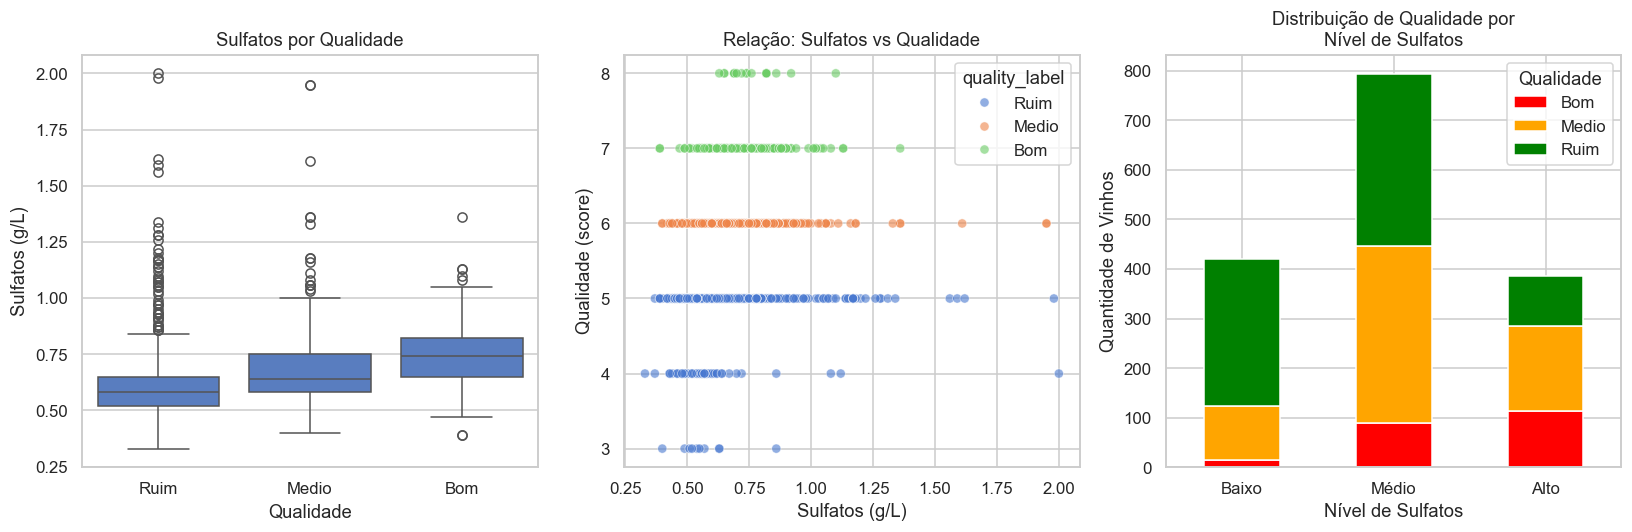

In [8]:
# DESCOBERTA 3: Impacto dos Sulfatos na Qualidade do Vinho

correlation_sulphates_quality = df['sulphates'].corr(df['quality'])
print(f'Correlação entre sulfatos e qualidade: {correlation_sulphates_quality:.3f}')

sulphates_stats = df.groupby('quality_label')['sulphates'].agg(['mean', 'median', 'std']).round(3)
print('\nEstatísticas de sulfatos por qualidade:')
print(sulphates_stats)

quartiles = df['sulphates'].quantile([0.25, 0.5, 0.75])
print(f'\nQuartis de sulfatos:')
for q, val in quartiles.items():
    print(f'Q{int(q*100)}: {val:.3f}')

df['sulphates_category'] = pd.cut(df['sulphates'], 
                                 bins=[0, quartiles[0.25], quartiles[0.75], float('inf')],
                                 labels=['Baixo', 'Médio', 'Alto'])

crosstab = pd.crosstab(df['sulphates_category'], df['quality_label'], normalize='index') * 100
print('\nDistribuição percentual de qualidade por nível de sulfatos:')
print(crosstab.round(1))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='quality_label', y='sulphates', order=['Ruim', 'Medio', 'Bom'])
plt.title('Sulfatos por Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Sulfatos (g/L)')

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='sulphates', y='quality', hue='quality_label', alpha=0.6)
plt.title('Relação: Sulfatos vs Qualidade')
plt.xlabel('Sulfatos (g/L)')
plt.ylabel('Qualidade (score)')

plt.subplot(1, 3, 3)
crosstab_values = pd.crosstab(df['sulphates_category'], df['quality_label'])
crosstab_values.plot(kind='bar', stacked=True, ax=plt.gca(), color=['red', 'orange', 'green'])
plt.title('Distribuição de Qualidade por\nNível de Sulfatos')
plt.xlabel('Nível de Sulfatos')
plt.ylabel('Quantidade de Vinhos')
plt.xticks(rotation=0)
plt.legend(title='Qualidade')

plt.tight_layout()
plt.show()

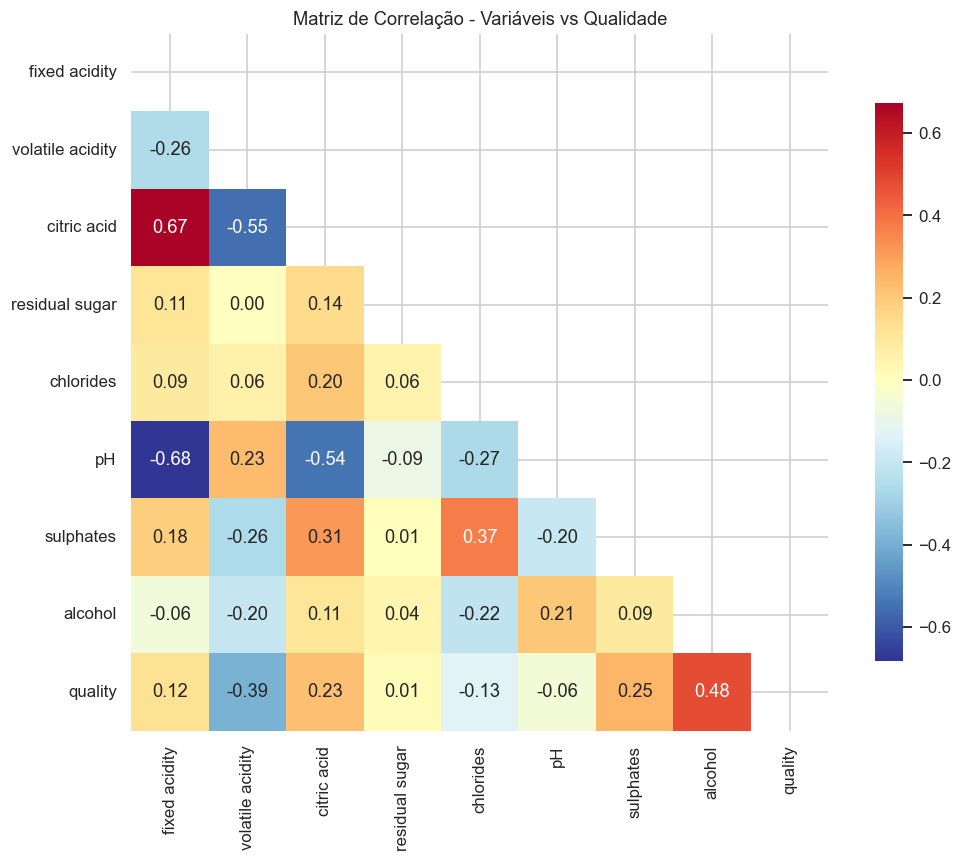


Top correlações com qualidade (valor absoluto):
alcohol: 0.476 (positiva)
volatile acidity: 0.391 (negativa)
sulphates: 0.251 (positiva)
citric acid: 0.226 (positiva)
chlorides: 0.129 (negativa)
fixed acidity: 0.124 (positiva)
pH: 0.058 (negativa)
residual sugar: 0.014 (positiva)


In [9]:
# ANÁLISE COMPLEMENTAR: Matriz de Correlação das Principais Variáveis

important_vars = ['fixed acidity', 'volatile acidity', 'citric acid', 
                  'residual sugar', 'chlorides', 'pH', 'sulphates', 'alcohol', 'quality']

correlation_matrix = df[important_vars].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdYlBu_r', 
            center=0, square=True, fmt='.2f', cbar_kws={'shrink': .8})
plt.title('Matriz de Correlação - Variáveis vs Qualidade')
plt.tight_layout()
plt.show()

quality_corr = correlation_matrix['quality'].abs().sort_values(ascending=False)[1:]
print('\nTop correlações com qualidade (valor absoluto):')
for var, corr in quality_corr.items():
    direction = 'positiva' if correlation_matrix['quality'][var] > 0 else 'negativa'
    print(f'{var}: {corr:.3f} ({direction})')

In [10]:
# RESUMO FINAL DAS DESCOBERTAS

print('='*60)
print('RESUMO DAS PRINCIPAIS DESCOBERTAS')
print('='*60)

print('\n1. TEOR ALCOÓLICO E QUALIDADE:')
print(f'   • Correlação positiva: {df["alcohol"].corr(df["quality"]):.3f}')
print(f'   • Vinhos bons: {df[df["quality_label"] == "Bom"]["alcohol"].mean():.2f}% álcool em média')
print(f'   • Vinhos ruins: {df[df["quality_label"] == "Ruim"]["alcohol"].mean():.2f}% álcool em média')
print(f'   • Diferença: {df[df["quality_label"] == "Bom"]["alcohol"].mean() - df[df["quality_label"] == "Ruim"]["alcohol"].mean():.2f} pontos percentuais')

print('\n2. ACIDEZ VOLÁTIL E QUALIDADE:')
print(f'   • Correlação negativa: {df["volatile acidity"].corr(df["quality"]):.3f}')
print(f'   • Vinhos bons: {df[df["quality_label"] == "Bom"]["volatile acidity"].mean():.3f} g/L em média')
print(f'   • Vinhos ruins: {df[df["quality_label"] == "Ruim"]["volatile acidity"].mean():.3f} g/L em média')
difference = df[df["quality_label"] == "Ruim"]["volatile acidity"].mean() - df[df["quality_label"] == "Bom"]["volatile acidity"].mean()
print(f'   • Vinhos ruins têm {difference:.3f} g/L mais acidez volátil')

print('\n3. SULFATOS E QUALIDADE:')
print(f'   • Correlação positiva: {df["sulphates"].corr(df["quality"]):.3f}')
print(f'   • Vinhos bons: {df[df["quality_label"] == "Bom"]["sulphates"].mean():.3f} g/L em média')
print(f'   • Vinhos ruins: {df[df["quality_label"] == "Ruim"]["sulphates"].mean():.3f} g/L em média')
sulph_diff = df[df["quality_label"] == "Bom"]["sulphates"].mean() - df[df["quality_label"] == "Ruim"]["sulphates"].mean()
print(f'   • Vinhos bons têm {sulph_diff:.3f} g/L mais sulfatos')

print('\n' + '='*60)
print(f'Análise completa de {len(df)} amostras de vinho tinto')
print('='*60)

RESUMO DAS PRINCIPAIS DESCOBERTAS

1. TEOR ALCOÓLICO E QUALIDADE:
   • Correlação positiva: 0.476
   • Vinhos bons: 11.52% álcool em média
   • Vinhos ruins: 9.93% álcool em média
   • Diferença: 1.59 pontos percentuais

2. ACIDEZ VOLÁTIL E QUALIDADE:
   • Correlação negativa: -0.391
   • Vinhos bons: 0.406 g/L em média
   • Vinhos ruins: 0.590 g/L em média
   • Vinhos ruins têm 0.184 g/L mais acidez volátil

3. SULFATOS E QUALIDADE:
   • Correlação positiva: 0.251
   • Vinhos bons: 0.743 g/L em média
   • Vinhos ruins: 0.619 g/L em média
   • Vinhos bons têm 0.125 g/L mais sulfatos

Análise completa de 1599 amostras de vinho tinto


In [ ]:
df_model = df.copy()

df_model['good_quality'] = (df_model['quality'] >= 7).astype(int)

print(f'Distribuição da variável target:')
print(df_model['good_quality'].value_counts())
print(f'\nProporção de vinhos de boa qualidade: {df_model["good_quality"].mean():.3f}')

In [ ]:
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
           'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
           'pH', 'sulphates', 'alcohol']

X = df_model[features]
y = df_model['good_quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Tamanho do conjunto de treino: {X_train.shape[0]}')
print(f'Tamanho do conjunto de teste: {X_test.shape[0]}')
print(f'\nDistribuição no treino:')
print(y_train.value_counts())
print(f'\nDistribuição no teste:')
print(y_test.value_counts())

In [ ]:
dummy_model = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)
dummy_accuracy = accuracy_score(y_test, dummy_pred)

print('BASELINE MODEL (DummyClassifier):')
print(f'Acurácia: {dummy_accuracy:.3f}')
print('\nRelatório de classificação:')
print(classification_report(y_test, dummy_pred))

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print('RANDOM FOREST CLASSIFIER:')
print(f'Acurácia: {rf_accuracy:.3f}')
print('\nRelatório de classificação:')
print(classification_report(y_test, rf_pred))

In [ ]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

print('LOGISTIC REGRESSION:')
print(f'Acurácia: {lr_accuracy:.3f}')
print('\nRelatório de classificação:')
print(classification_report(y_test, lr_pred))

In [ ]:
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importância')
plt.title('Importância das Variáveis - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nImportância das variáveis:')
for i, row in feature_importance.iterrows():
    print(f'{row["feature"]}: {row["importance"]:.3f}')

In [ ]:
print('COMPARAÇÃO DOS MODELOS:')
print('='*50)
print(f'Baseline (DummyClassifier): {dummy_accuracy:.3f}')
print(f'Random Forest:              {rf_accuracy:.3f}')
print(f'Logistic Regression:        {lr_accuracy:.3f}')
print('='*50)

best_model = 'Random Forest' if rf_accuracy >= lr_accuracy else 'Logistic Regression'
best_accuracy = max(rf_accuracy, lr_accuracy)
improvement = best_accuracy - dummy_accuracy

print(f'\nMelhor modelo: {best_model}')
print(f'Acurácia: {best_accuracy:.3f}')
print(f'Melhoria sobre baseline: {improvement:.3f} ({improvement/dummy_accuracy:.1%})')

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import KFold
import numpy as np

class ClassificadorAleatorio(BaseEstimator, ClassifierMixin):
    """Classificador que faz predições completamente aleatórias"""
    
    def __init__(self, random_state=42):
        self.random_state = random_state
    
    def fit(self, X, y):
        """Armazena as classes únicas do target durante o treino"""
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        return self
    
    def predict(self, X):
        """Faz predições completamente aleatórias baseadas nas classes conhecidas"""
        np.random.seed(self.random_state)
        return np.random.choice(self.classes_, size=len(X))

print("✅ Classificador Aleatório criado com sucesso!")

In [ ]:
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

models = {
    'Baseline (Dummy)': DummyClassifier(strategy='most_frequent', random_state=42),
    'Classificador Aleatório': ClassificadorAleatorio(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

cv_scores = {name: [] for name in models.keys()}

print(f'Executando {k_folds}-Fold Cross Validation...')
print('='*60)

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    
    print(f'\nFold {fold}:')
    print(f'  Treino: {len(X_train_fold)} amostras | Teste: {len(X_test_fold)} amostras')
    
    for name, model in models.items():
        model.fit(X_train_fold, y_train_fold)
        predictions = model.predict(X_test_fold)
        accuracy = accuracy_score(y_test_fold, predictions)
        cv_scores[name].append(accuracy)
        print(f'  {name}: {accuracy:.4f}')

print('\n' + '='*60)
print('RESULTADOS FINAIS K-FOLD CROSS VALIDATION')
print('='*60)

for name, scores in cv_scores.items():
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f'{name:<20}: {mean_score:.4f} ± {std_score:.4f}')
    print(f'                    Scores por fold: {[f"{s:.4f}" for s in scores]}')
    print()

In [ ]:
import matplotlib.pyplot as plt

model_names = list(cv_scores.keys())
means = [np.mean(scores) for scores in cv_scores.values()]
stds = [np.std(scores) for scores in cv_scores.values()]

plt.figure(figsize=(12, 8))
bars = plt.bar(model_names, means, yerr=stds, capsize=5, alpha=0.7, 
               color=['red', 'orange', 'green', 'blue'])
plt.xlabel('Modelos')
plt.ylabel('Acurácia')
plt.title(f'Comparação de Modelos - {k_folds}-Fold Cross Validation')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar, mean, std in zip(bars, means, stds):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + std + 0.01,
             f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(means) + max(stds) + 0.1)
plt.tight_layout()
plt.show()

melhor_modelo = model_names[np.argmax(means)]
melhor_score = max(means)
print(f'\n🏆 Melhor modelo: {melhor_modelo} ({melhor_score:.4f})')